# Suitability Index: Land Cover with Feedstock Integration

This notebook is a thin wrapper around `1_1_SI_Landcover_feedstock.py`, which contains the maintained feedstock integration workflow.


## Step 1: Load the feedstock integration function


In [1]:
from pathlib import Path
import runpy

module = runpy.run_path('1_1_SI_Landcover_feedstock.py')
process_landcover_feedstock = module['process_landcover_feedstock']


## Step 2: Build the full-area feedstock landcover layer


In [2]:
process_landcover_feedstock(
    input_path=Path('Output') / 'xr_SI_Landcover_beforefeedstock.nc',
    output_path=Path('Output') / 'xr_SI_Landcover.nc',
)


Loading pre-feedstock landcover SI from Output\xr_SI_Landcover_beforefeedstock.nc...
Loading Thailand provincial boundaries...
Loaded 77 provinces
Assigning grid points to provinces...


1_1_SI_Landcover_feedstock.py:51: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  prov_centroids = np.column_stack((thailandmap.geometry.centroid.x, thailandmap.geometry.centroid.y))


Assigned 15957810 points in 6.12s
Loaded feedstock: 217 records | 77 provinces
Distributing feedstock potential...
  A_Biomass: Distributed to 64 provinces
  A_BGEC: Distributed to 77 provinces
  A_BGWW: Distributed to 77 provinces
  A_MSW: Distributed to 74 provinces
  A_IEW: Distributed to 74 provinces
  A_BGEC: 1840.17 ktoe
  A_Biomass: 58670.21 ktoe
  A_BGWW: 1840.17 ktoe
  A_MSW: 5971.58 ktoe
  A_IEW: 5971.58 ktoe
Saving feedstock-integrated landcover SI to Output\xr_SI_Landcover.nc...
Feedstock integration completed.


## Optional: Preview Output

Run this cell after the build if you want to inspect the resulting dataset.


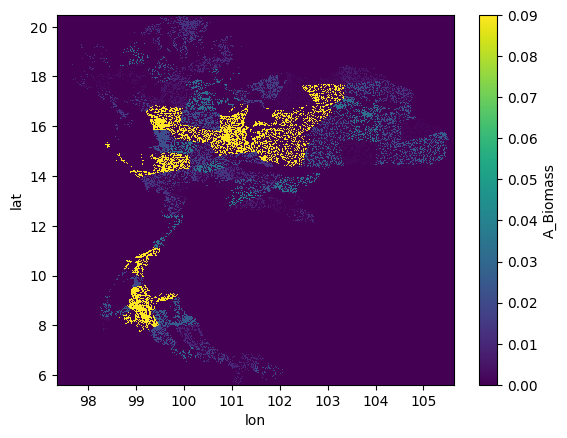

In [3]:
import xarray as xr

xr_areafeedstock = xr.open_dataset(Path('Output') / 'xr_SI_Landcover.nc')
xr_areafeedstock['A_Biomass'].plot()
